In [33]:
import os
import pandas as pd
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')
import re
import openpyxl
import numpy as np

In [34]:
folder=r'C:\Users\vikram.vadhirajan\OneDrive - Trico\Documents - Product Support India Romania\Catalog\Score card\Standard\GM_Update'
OFolder=r'C:\Users\vikram.vadhirajan\OneDrive - Trico\Documents - Product Support India Romania\Catalog\Score card\Standard\GM_Update'

In [35]:
file_list=[]
for (root, dirs, file) in os.walk(folder):
    for f in file:
        if ('.xlsx') in f:

                    file_list.append(f)
file_list

['Brake Bleeder Screw.xlsx',
 'Brake Drum.xlsx',
 'Brake Hydraulic Hose.xlsx',
 'Brake Master Cylinder.xlsx',
 'Disc Brake Caliper Pin Kit.xlsx',
 'Disc Brake Caliper Pin.xlsx',
 'Disc Brake Caliper Piston.xlsx',
 'Disc Brake Caliper Set.xlsx',
 'Disc Brake Caliper.xlsx',
 'Disc Brake Hardware Kit.xlsx',
 'Disc Brake Pad Set.xlsx',
 'Disc Brake Pad Wear Sensor.xlsx',
 'Disc Brake Rotor and Hub Assembly.xlsx',
 'Disc Brake Rotor.xlsx',
 'Drum Brake Hardware Kit.xlsx',
 'Drum Brake Shoe.xlsx',
 'Drum Brake Wheel Cylinder.xlsx',
 'Parking Brake Cable.xlsx',
 'Parking Brake Disc Brake Pad Set.xlsx',
 'Parking Brake Hardware Kit.xlsx',
 'Parking Brake Shoe.xlsx']

In [36]:
file_link=[]

for i in range(len(file_list)):
     for r,d,f in os.walk(folder):
          for files in f:
               if files == file_list[i]:
                    file_link.append(os.path.join(r,files))

In [37]:
len(file_link)

21

In [38]:
file_link[1]

'C:\\Users\\vikram.vadhirajan\\OneDrive - Trico\\Documents - Product Support India Romania\\Catalog\\Score card\\Standard\\GM_Update\\Brake Drum.xlsx'

In [39]:
cols=["Article Number",
"Brand",
"Region",
"Product Group",
"Product Group Overrides",
"Product Line",
"Publishing Countries",
"Article Status Code",
"Article Status Description",
"Children article numbers",
"Attribute",
"Value",
]
df_s = pd.DataFrame(columns=cols)
df_s


,Article Number,Brand,Region,Product Group,Product Group Overrides,Product Line,Publishing Countries,Article Status Code,Article Status Description,Children article numbers,Attribute,Value


In [40]:
repl='''C:\\Users\\Vikram.Vadhirajan\\OneDrive - Trico\\Documents - Product Support India Romania\\Catalog\\Score card\\Standard\\GM_Update\\'''
IDS=["Article Number",
"Brand",
"Region",
"Product Group",
"Product Group Overrides",
"Product Line",
"Publishing Countries",
"Article Status Code",
"Article Status Description",
"Children article numbers",]

In [41]:
for i in range(len(file_link)):
    workbook=openpyxl.load_workbook(file_link[i])
    print(file_link[i])
    df=pd.read_excel(file_link[i],sheet_name="article-export")
    df=pd.melt(df,id_vars=IDS,var_name="Attribute",value_name="Value").reset_index(drop=True)
    df_s=pd.concat([df_s,df])   


C:\Users\vikram.vadhirajan\OneDrive - Trico\Documents - Product Support India Romania\Catalog\Score card\Standard\GM_Update\Brake Bleeder Screw.xlsx
C:\Users\vikram.vadhirajan\OneDrive - Trico\Documents - Product Support India Romania\Catalog\Score card\Standard\GM_Update\Brake Drum.xlsx
C:\Users\vikram.vadhirajan\OneDrive - Trico\Documents - Product Support India Romania\Catalog\Score card\Standard\GM_Update\Brake Hydraulic Hose.xlsx
C:\Users\vikram.vadhirajan\OneDrive - Trico\Documents - Product Support India Romania\Catalog\Score card\Standard\GM_Update\Brake Master Cylinder.xlsx
C:\Users\vikram.vadhirajan\OneDrive - Trico\Documents - Product Support India Romania\Catalog\Score card\Standard\GM_Update\Disc Brake Caliper Pin Kit.xlsx
C:\Users\vikram.vadhirajan\OneDrive - Trico\Documents - Product Support India Romania\Catalog\Score card\Standard\GM_Update\Disc Brake Caliper Pin.xlsx
C:\Users\vikram.vadhirajan\OneDrive - Trico\Documents - Product Support India Romania\Catalog\Score ca

<Axes: >

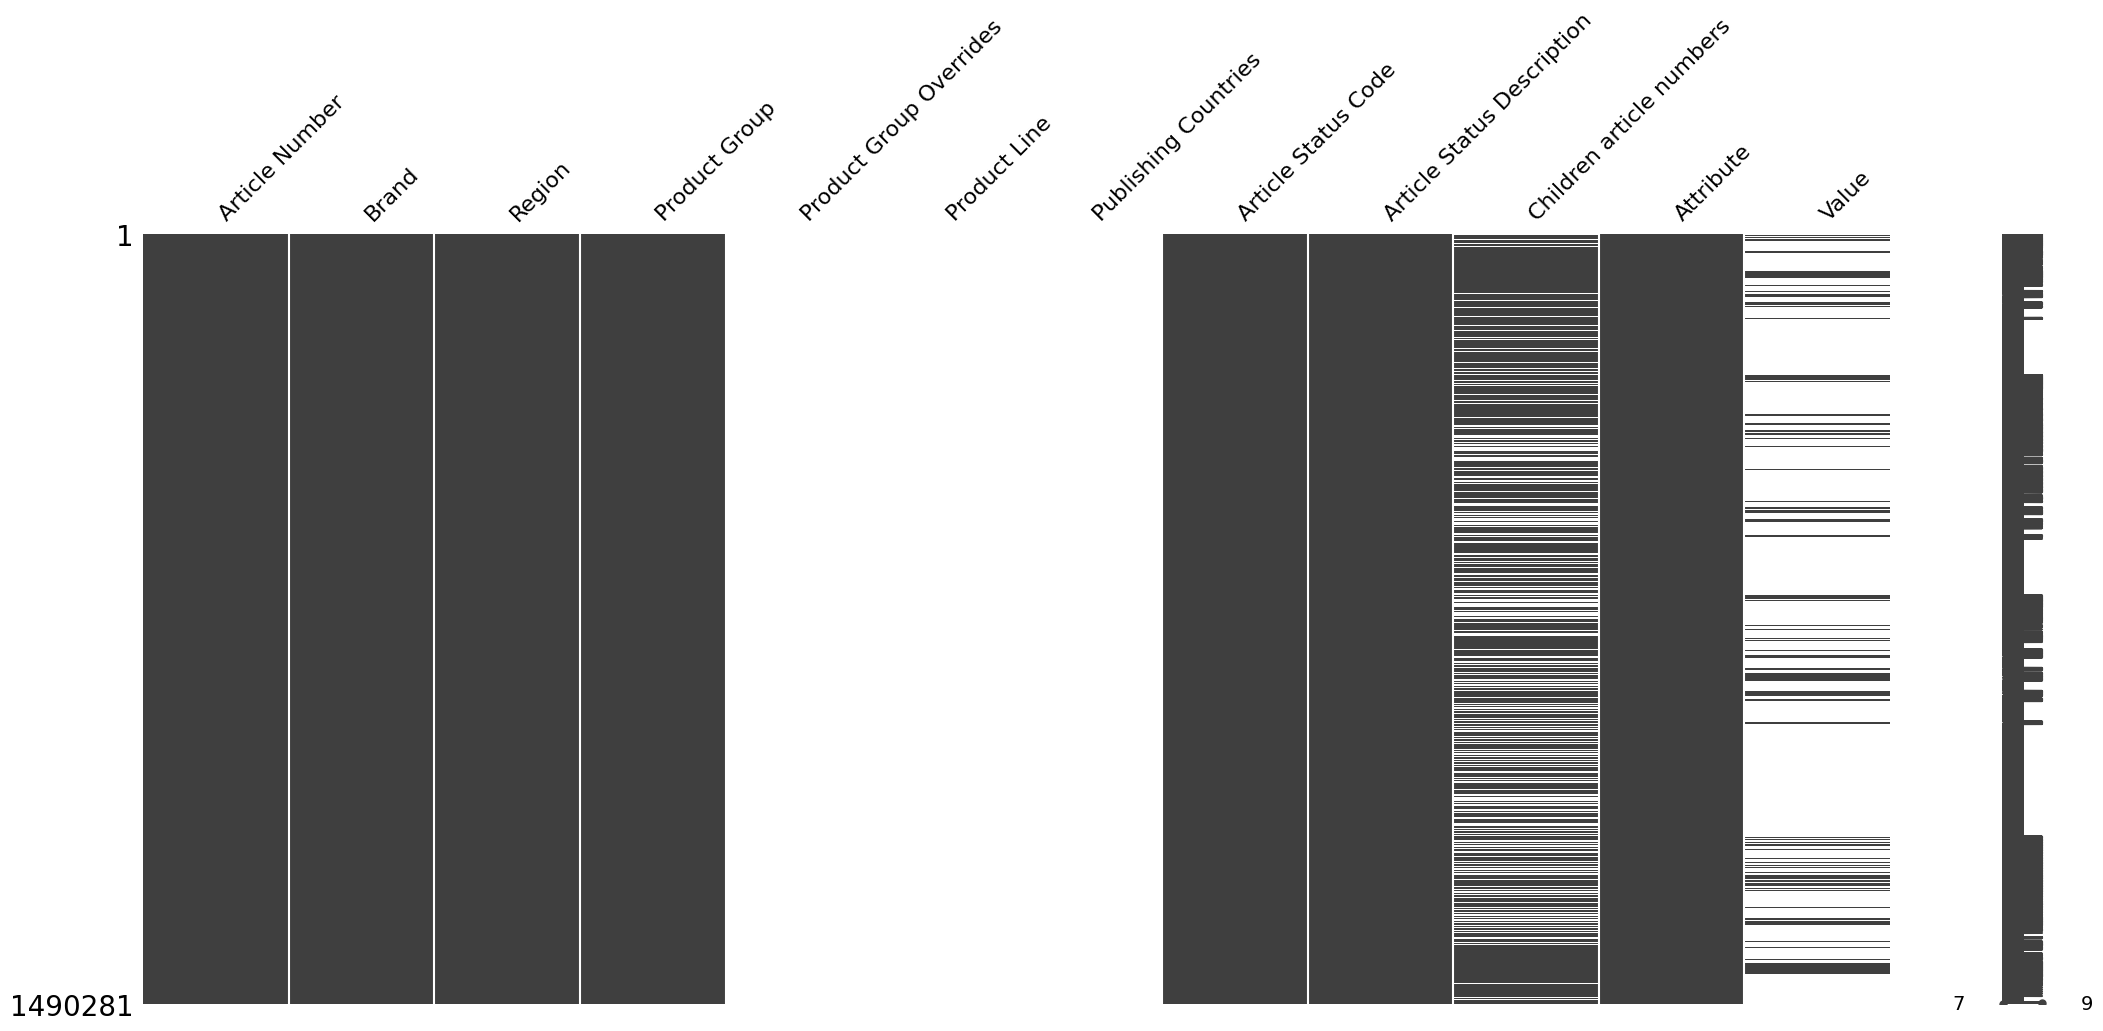

In [42]:
import missingno as msno 
msno.matrix(df_s)

In [43]:
df_Final=df_s[['Article Number', 'Product Group',
       'Article Status Description',
       'Children article numbers', 'Attribute', 'Value']]
df_Final

,Article Number,Product Group,Article Status Description,Children article numbers,Attribute,Value
0,10591,Brake Bleeder Screw,Available,"S10591,10591,19307935,18K2362 (19307935)",Bleeder Screw Thread Size,NaN
1,11410,Brake Bleeder Screw,Available,"S11410-2,S11410,11410,19307920,18K2347 (19307920)",Bleeder Screw Thread Size,"7/16""-20"
2,11579,Brake Bleeder Screw,Available,"11579,S11579,S11579-2",Bleeder Screw Thread Size,"3/8""-24"
3,11596,Brake Bleeder Screw,Available,"S11596,11596,19382911,18K11596 (19382911)",Bleeder Screw Thread Size,NaN
4,20089,Brake Bleeder Screw,Available,"S20089,20089,19307908,S20089-2,18K2335 (19307908)",Bleeder Screw Thread Size,"5/16""-24"
...,...,...,...,...,...,...
3131,S986,Parking Brake Shoe,Available,"986PG,BS986,19310513,17986B (19310513)",Friction Material,NaN
3132,S987,Parking Brake Shoe,Available,"987PG,BS987,19384057,17987B (19384057)",Friction Material,NaN
3133,S988,Parking Brake Shoe,Available,"988PG,BS988,19310514,17988B (19310514)",Friction Material,NaN
3134,S989,Parking Brake Shoe,Available,"989PG,BS989,19310515,17989B (19310515)",Friction Material,NaN


In [44]:
df_Final=df_Final[df_Final["Attribute"].str.startswith("(")==False]

In [45]:
df_Final.dropna(subset=['Value'], inplace=True)
df_Final

,Article Number,Product Group,Article Status Description,Children article numbers,Attribute,Value
1,11410,Brake Bleeder Screw,Available,"S11410-2,S11410,11410,19307920,18K2347 (19307920)",Bleeder Screw Thread Size,"7/16""-20"
2,11579,Brake Bleeder Screw,Available,"11579,S11579,S11579-2",Bleeder Screw Thread Size,"3/8""-24"
4,20089,Brake Bleeder Screw,Available,"S20089,20089,19307908,S20089-2,18K2335 (19307908)",Bleeder Screw Thread Size,"5/16""-24"
10,22163,Brake Bleeder Screw,Available,"S22163,22163,19307983,18K2410 (19307983)",Bleeder Screw Thread Size,M10-1.00
11,22430,Brake Bleeder Screw,Available,"S22430,22430,19307912,18K2339 (19307912)",Bleeder Screw Thread Size,M8-1.25
...,...,...,...,...,...,...
2011,S986,Parking Brake Shoe,Available,"986PG,BS986,19310513,17986B (19310513)",Toe Location (in),0.591
2012,S987,Parking Brake Shoe,Available,"987PG,BS987,19384057,17987B (19384057)",Toe Location (in),0.67
2013,S988,Parking Brake Shoe,Available,"988PG,BS988,19310514,17988B (19310514)",Toe Location (in),1.55
2014,S989,Parking Brake Shoe,Available,"989PG,BS989,19310515,17989B (19310515)",Toe Location (in),0.75


In [46]:
df_Final.to_csv('Combined_Data.csv', index=False)

In [47]:
df_articlemap=df_Final[['Article Number','Children article numbers']]
df_articlemap=df_articlemap.drop_duplicates().reset_index(drop=True)

In [48]:
df_articlemap['Children article numbers'] = df_articlemap['Children article numbers'].str.split(',')
df_articlemap=df_articlemap.explode('Children article numbers')
df_articlemap=df_articlemap.reset_index(drop=True)

In [49]:
df_articlemap.to_csv('BaseChildMap.csv', index=False)